# Notebook 2: Correlation Analysis

Analyze correlations between MSFT and other tech stocks.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_all_stocks
from src.data_cleaner import clean_data
from src.analyzer import calculate_correlation_matrix, identify_correlations
from src.visualizer import plot_correlation_heatmap
from config.config import PRIMARY_STOCK, ALL_STOCKS

print('✅ All imports successful!')


✅ All imports successful!


## Load and Prepare Data

In [2]:
# Load stocks
stocks_data = load_all_stocks()

# Clean data
clean_stocks = {}
for ticker, data in stocks_data.items():
    clean_stocks[ticker] = clean_data(data, ticker)

print('✅ Data loaded and cleaned!')



LOADING STOCK DATA



✅ Successfully downloaded 252 records for MSFT
✅ Successfully downloaded 252 records for AAPL


✅ Successfully downloaded 252 records for GOOGL
✅ Successfully downloaded 252 records for NVDA


✅ Successfully downloaded 252 records for TSLA

✅ Loaded data for 5 stocks

Cleaning MSFT data...
Missing values before: 0
Missing values after: 0
✅ Cleaned data shape: (252, 5)

Cleaning AAPL data...
Missing values before: 0
Missing values after: 0
✅ Cleaned data shape: (252, 5)

Cleaning GOOGL data...
Missing values before: 0
Missing values after: 0
✅ Cleaned data shape: (252, 5)

Cleaning NVDA data...
Missing values before: 0
Missing values after: 0
✅ Cleaned data shape: (252, 5)

Cleaning TSLA data...
Missing values before: 0
Missing values after: 0
✅ Cleaned data shape: (252, 5)
✅ Data loaded and cleaned!


## Calculate Correlation Matrix

In [3]:
# Calculate correlations
corr_matrix = calculate_correlation_matrix(clean_stocks)

print('\nCorrelation Matrix:')
print(corr_matrix.round(3))



Calculating correlation matrix...
✅ Correlation matrix calculated

Correlation Matrix:
        MSFT   AAPL  GOOGL   NVDA   TSLA
MSFT   1.000 -0.464 -0.651 -0.326 -0.054
AAPL  -0.464  1.000  0.913  0.811  0.729
GOOGL -0.651  0.913  1.000  0.785  0.625
NVDA  -0.326  0.811  0.785  1.000  0.489
TSLA  -0.054  0.729  0.625  0.489  1.000


## Visualize Correlation Heatmap

Saved plot: visualizations/correlation_heatmap.png


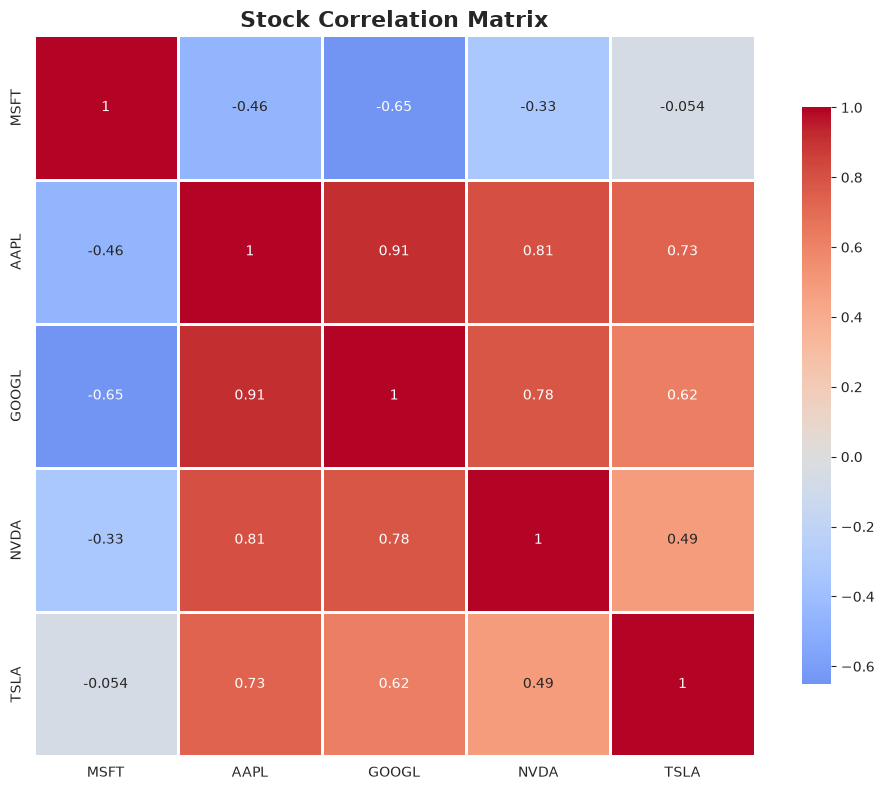

In [4]:
# Plot heatmap
plot_correlation_heatmap(corr_matrix)


## Identify High Correlations

In [5]:
# Find high correlations (threshold > 0.7)
high_corr = identify_correlations(corr_matrix, threshold=0.7)

print('\n' + '='*80)
print('HIGHLY CORRELATED STOCK PAIRS (> 0.7)')
print('='*80)

if high_corr:
    for pair in high_corr:
        print(f'{pair["Stock1"]} <-> {pair["Stock2"]}: {pair["Correlation"]:.3f}')
else:
    print('No pairs with correlation > 0.7')

# Find moderate correlations (threshold > 0.5)
mod_corr = identify_correlations(corr_matrix, threshold=0.5)

print('\n' + '='*80)
print('MODERATELY CORRELATED PAIRS (> 0.5)')
print('='*80)

if mod_corr:
    for pair in mod_corr:
        print(f'{pair["Stock1"]} <-> {pair["Stock2"]}: {pair["Correlation"]:.3f}')
else:
    print('No pairs with correlation > 0.5')



HIGHLY CORRELATED STOCK PAIRS (> 0.7)
AAPL <-> GOOGL: 0.913
AAPL <-> NVDA: 0.811
AAPL <-> TSLA: 0.729
GOOGL <-> NVDA: 0.785

MODERATELY CORRELATED PAIRS (> 0.5)
MSFT <-> GOOGL: -0.651
AAPL <-> GOOGL: 0.913
AAPL <-> NVDA: 0.811
AAPL <-> TSLA: 0.729
GOOGL <-> NVDA: 0.785
GOOGL <-> TSLA: 0.625


## Analyze MSFT Correlations

In [6]:
print('\n' + '='*80)
print(f'MSFT CORRELATION WITH OTHER STOCKS')
print('='*80)

msft_corr = corr_matrix[PRIMARY_STOCK].drop(PRIMARY_STOCK).sort_values(ascending=False)

for stock, corr_value in msft_corr.items():
    print(f'{stock}: {corr_value:.3f}')



MSFT CORRELATION WITH OTHER STOCKS
TSLA: -0.054
NVDA: -0.326
AAPL: -0.464
GOOGL: -0.651


## Price Movement Comparison

Saved: visualizations/correlation_performance_comparison.png


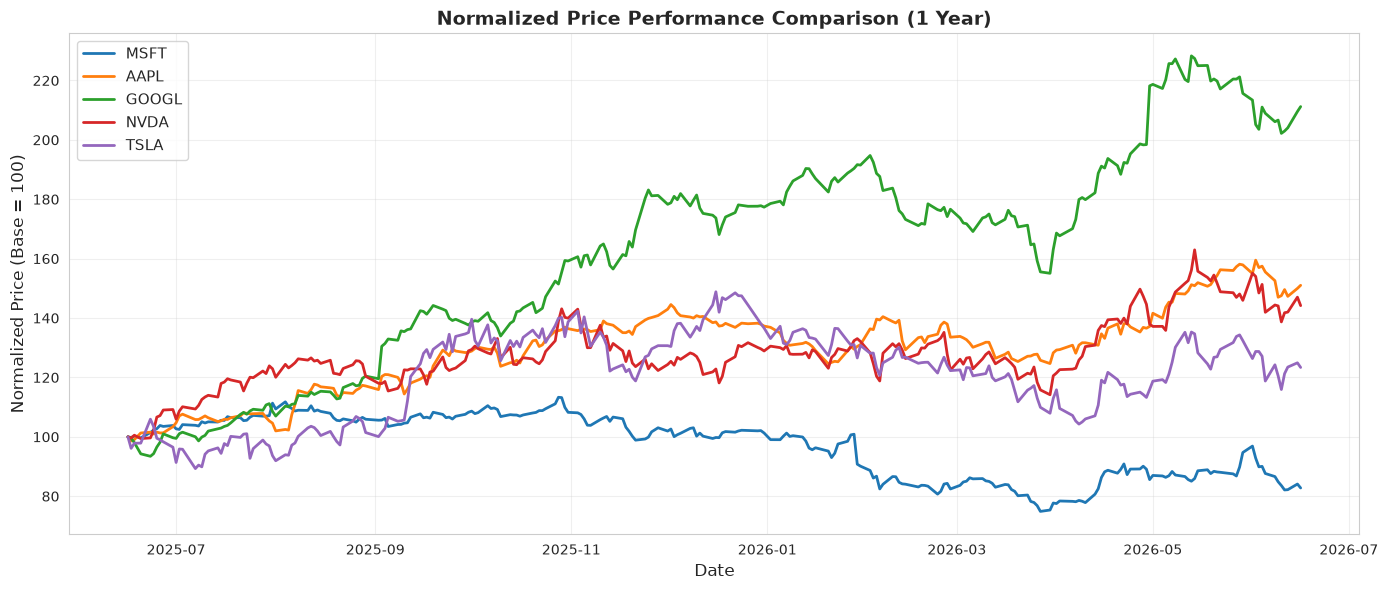

In [7]:
# Create moving average comparison
fig, ax = plt.subplots(figsize=(14, 6))

for ticker in ALL_STOCKS:
    # Normalize to 100 at start
    normalized = (clean_stocks[ticker]['Close'] / clean_stocks[ticker]['Close'].iloc[0]) * 100
    ax.plot(normalized.index, normalized, label=ticker, linewidth=2)

ax.set_title('Normalized Price Performance Comparison (1 Year)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalized Price (Base = 100)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/correlation_performance_comparison.png', dpi=300, bbox_inches='tight')
print('Saved: visualizations/correlation_performance_comparison.png')
plt.show()


## Key Insights from Correlation Analysis

In [8]:
print('\n' + '='*80)
print('CORRELATION INSIGHTS')
print('='*80)

print(f'\n1. MSFT is most correlated with: {msft_corr.idxmax()} ({msft_corr.max():.3f})')
print(f'2. MSFT is least correlated with: {msft_corr.idxmin()} ({msft_corr.min():.3f})')

print('\n3. Interpretation:')
print('   - Strong correlation (>0.7) indicates stocks move together')
print('   - Moderate correlation (0.5-0.7) indicates related movements')
print('   - Tech stocks often correlate due to similar market factors')

print('\n✅ Correlation analysis complete! Proceed to predictive modeling.')



CORRELATION INSIGHTS

1. MSFT is most correlated with: TSLA (-0.054)
2. MSFT is least correlated with: GOOGL (-0.651)

3. Interpretation:
   - Strong correlation (>0.7) indicates stocks move together
   - Moderate correlation (0.5-0.7) indicates related movements
   - Tech stocks often correlate due to similar market factors

✅ Correlation analysis complete! Proceed to predictive modeling.
